In [1]:
# conection to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# unziping dataset
!unzip /content/drive/MyDrive/data/Animals-10.zip -d /content/dataset

Archive:  /content/drive/MyDrive/data/Animals-10.zip
replace /content/dataset/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
from PIL import Image
from collections import Counter

import torch
import torchvision
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
from torchvision.io import read_image

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **loading data**

In [4]:
# counting number of images in classes
path = '/content/dataset/raw-img'
classes = os.listdir(path)

class_names = {}
for class_name in classes:
  class_names[class_name] = len(os.listdir(os.path.join(path, class_name)))

class_names

{'gatto': 1668,
 'gallina': 3098,
 'cavallo': 2623,
 'scoiattolo': 1862,
 'pecora': 1820,
 'elefante': 1446,
 'farfalla': 2112,
 'ragno': 4821,
 'cane': 4863,
 'mucca': 1866}

In [5]:
# sorting classes distribution for visualization
class_names_sorted = dict(reversed(sorted(class_names.items(), key=lambda item: item[1])))
class_names_sorted

{'cane': 4863,
 'ragno': 4821,
 'gallina': 3098,
 'cavallo': 2623,
 'farfalla': 2112,
 'mucca': 1866,
 'scoiattolo': 1862,
 'pecora': 1820,
 'gatto': 1668,
 'elefante': 1446}

In [6]:
IMAGE_SIZE = (64, 64)
MEANS = [0.517645001411438, 0.5002366304397583, 0.4124912917613983]
STDS = [0.2544998228549957, 0.2494899481534958, 0.2677474021911621]

In [7]:
# conversion to tensors
transform_test = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),                                   # setting one size for all images
    transforms.ToTensor(),                                           # converting to tensors
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [8]:
# conversion to tensors
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),        # setting one size for all images
    transforms.RandomHorizontalFlip(),    # random horiz flip of images
    transforms.RandomRotation(15),        # random rotation
    transforms.ToTensor(),                # converting to tensors
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [9]:
# loading dataset
data = torchvision.datasets.ImageFolder(root='/content/dataset/raw-img', transform=None)

In [10]:
# getting classes names
classes = data.classes
print(f'data classes: {classes}, number of classes: {len(classes)}')

data classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'], number of classes: 10


In [11]:
# transtating classes to english
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow",
             "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"}
classes_eng = [translate[animal] for animal in translate]

In [12]:
print(f'data classes: {classes_eng}, number of classes: {len(classes_eng)}')

data classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel'], number of classes: 10


In [13]:
data.classes

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [14]:
data.class_to_idx

{'cane': 0,
 'cavallo': 1,
 'elefante': 2,
 'farfalla': 3,
 'gallina': 4,
 'gatto': 5,
 'mucca': 6,
 'pecora': 7,
 'ragno': 8,
 'scoiattolo': 9}

In [15]:
counter = Counter(data.targets)
counter, data.class_to_idx

(Counter({0: 4863,
          1: 2623,
          2: 1446,
          3: 2112,
          4: 3098,
          5: 1668,
          6: 1866,
          7: 1820,
          8: 4821,
          9: 1862}),
 {'cane': 0,
  'cavallo': 1,
  'elefante': 2,
  'farfalla': 3,
  'gallina': 4,
  'gatto': 5,
  'mucca': 6,
  'pecora': 7,
  'ragno': 8,
  'scoiattolo': 9})

# **dividing dataset to train and test**

In [16]:
def count_classes(dataset):
    labels = [dataset.dataset.targets[i] for i in dataset.indices]
    class_counts = Counter(labels)
    for class_idx, count in class_counts.items():
        class_name = dataset.dataset.classes[class_idx]
        print(f"Class:\t{class_name} - {classes_eng[class_idx]:<20}Instances: {count:<10} Percent: {count / counter[class_idx] * 100}%")

In [17]:
# dividing dataset to train, validation and test
train_size = int(len(data) * 0.6)
test_size = int(len(data) * 0.2)
val_size = int(len(data) - train_size - test_size)

train_data, test_data, valid_data = random_split(dataset=data, lengths=[train_size, test_size, val_size])
print(f'train: {len(train_data):<20} test: {len(test_data):<20} validation: {len(valid_data)}')

train: 15707                test: 5235                 validation: 5237


In [18]:
count_classes(train_data)

Class:	cane - dog                 Instances: 2920       Percent: 60.04523956405511%
Class:	mucca - cow                 Instances: 1127       Percent: 60.39657020364416%
Class:	scoiattolo - squirrel            Instances: 1146       Percent: 61.54672395273899%
Class:	gallina - chicken             Instances: 1863       Percent: 60.135571336346025%
Class:	farfalla - butterfly           Instances: 1220       Percent: 57.765151515151516%
Class:	pecora - sheep               Instances: 1124       Percent: 61.75824175824176%
Class:	cavallo - horse               Instances: 1596       Percent: 60.8463591307663%
Class:	ragno - spider              Instances: 2858       Percent: 59.28230657539929%
Class:	elefante - elephant            Instances: 848        Percent: 58.64453665283541%
Class:	gatto - cat                 Instances: 1005       Percent: 60.251798561151084%


In [19]:
count_classes(test_data)

Class:	gatto - cat                 Instances: 330        Percent: 19.784172661870503%
Class:	cane - dog                 Instances: 951        Percent: 19.55582973473165%
Class:	cavallo - horse               Instances: 520        Percent: 19.824628288219596%
Class:	ragno - spider              Instances: 949        Percent: 19.684712715204313%
Class:	gallina - chicken             Instances: 623        Percent: 20.10974822466107%
Class:	elefante - elephant            Instances: 317        Percent: 21.922544951590595%
Class:	farfalla - butterfly           Instances: 443        Percent: 20.97537878787879%
Class:	scoiattolo - squirrel            Instances: 376        Percent: 20.193340494092375%
Class:	pecora - sheep               Instances: 339        Percent: 18.626373626373628%
Class:	mucca - cow                 Instances: 387        Percent: 20.739549839228296%


In [20]:
count_classes(valid_data)

Class:	farfalla - butterfly           Instances: 449        Percent: 21.259469696969695%
Class:	ragno - spider              Instances: 1014       Percent: 21.03298070939639%
Class:	gallina - chicken             Instances: 612        Percent: 19.7546804389929%
Class:	cavallo - horse               Instances: 507        Percent: 19.32901258101411%
Class:	pecora - sheep               Instances: 357        Percent: 19.615384615384617%
Class:	mucca - cow                 Instances: 352        Percent: 18.863879957127548%
Class:	gatto - cat                 Instances: 333        Percent: 19.964028776978417%
Class:	cane - dog                 Instances: 992        Percent: 20.398930701213242%
Class:	scoiattolo - squirrel            Instances: 340        Percent: 18.259935553168635%
Class:	elefante - elephant            Instances: 281        Percent: 19.432918395574%


## **adding transformation to datasets**

In [21]:
class SubsetWithTransform():
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [22]:
train_data = SubsetWithTransform(train_data, transform=transform)
test_data = SubsetWithTransform(test_data, transform=transform_test)
valid_data = SubsetWithTransform(valid_data, transform=transform)

In [23]:
train_data.transform, test_data.transform, valid_data.transform

(Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677

# **part 3**
*Автоматизована оптимізація*

In [24]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, filters=[32, 64, 128, 256], fc_units=[512, 256, 128]):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, filters[0], kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(filters[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(filters[0], filters[1], kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(filters[1], filters[2], kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(filters[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(filters[2], filters[3], kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(filters[3])
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self._to_linear = None
        self.convs(torch.zeros(1, in_channels, 64, 64))

        self.fc1 = nn.Linear(self._to_linear, fc_units[0])
        self.fc2 = nn.Linear(fc_units[0], fc_units[1])
        self.fc3 = nn.Linear(fc_units[1], fc_units[2])
        self.fc4 = nn.Linear(fc_units[2], num_classes)

    def convs(self, x):
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool3(x)
        x = F.relu(self.conv4(x))
        x = self.bn4(x)
        x = self.pool4(x)

        if self._to_linear is None:
            self._to_linear = x.view(x.size(0), -1).size(1)
        return x

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [25]:
!pip install optuna

In [26]:
import optuna
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from torch import optim

In [27]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    filters = [
        trial.suggest_int('conv1_filters', 16, 64, step=16),
        trial.suggest_int('conv2_filters', 32, 128, step=32),
        trial.suggest_int('conv3_filters', 64, 256, step=64),
        trial.suggest_int('conv4_filters', 128, 512, step=128),
    ]
    fc_units = [
        trial.suggest_int('fc1_units', 256, 1024, step=256),
        trial.suggest_int('fc2_units', 128, 512, step=128),
        trial.suggest_int('fc3_units', 64, 256, step=64),
    ]
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

    trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

    model = CNNModel(filters=filters, fc_units=fc_units)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr) if optimizer_name == 'Adam' else torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(1):
        running_loss = 0.0
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

In [28]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

results_dict = {
    "trial_number": [],
    "params": [],
    "accuracy": []
}

for trial in study.trials:
    results_dict["trial_number"].append(trial.number)
    results_dict["params"].append(trial.params)
    results_dict["accuracy"].append(trial.value)

print("Best parameters found: ", study.best_params)

[I 2025-04-02 06:16:18,962] A new study created in memory with name: no-name-99cdf6db-e84a-4a6d-9dc9-3004190a9795
[I 2025-04-02 06:16:53,877] Trial 0 finished with value: 0.28443170964660935 and parameters: {'lr': 0.028214719535068603, 'batch_size': 32, 'conv1_filters': 64, 'conv2_filters': 64, 'conv3_filters': 64, 'conv4_filters': 384, 'fc1_units': 256, 'fc2_units': 128, 'fc3_units': 256, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.28443170964660935.
[I 2025-04-02 06:17:16,162] Trial 1 finished with value: 0.18166189111747852 and parameters: {'lr': 0.02211116545762614, 'batch_size': 32, 'conv1_filters': 64, 'conv2_filters': 32, 'conv3_filters': 64, 'conv4_filters': 384, 'fc1_units': 512, 'fc2_units': 128, 'fc3_units': 256, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.28443170964660935.
[I 2025-04-02 06:17:38,713] Trial 2 finished with value: 0.4510028653295129 and parameters: {'lr': 0.0005023776950030632, 'batch_size': 32, 'conv1_filters': 64, 'conv2_filters': 32, 'conv3

Best parameters found:  {'lr': 0.0003359902842986991, 'batch_size': 128, 'conv1_filters': 16, 'conv2_filters': 64, 'conv3_filters': 256, 'conv4_filters': 512, 'fc1_units': 768, 'fc2_units': 384, 'fc3_units': 128, 'optimizer': 'Adam'}


In [29]:
best_params = study.best_params
best_params

{'lr': 0.0003359902842986991,
 'batch_size': 128,
 'conv1_filters': 16,
 'conv2_filters': 64,
 'conv3_filters': 256,
 'conv4_filters': 512,
 'fc1_units': 768,
 'fc2_units': 384,
 'fc3_units': 128,
 'optimizer': 'Adam'}

# **Apply best parameters**

## **creating data loaders**

In [30]:
num_workers = 2

In [31]:
batch_size=best_params['batch_size']
batch_size

128

In [32]:
# creating data loader
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
data_loader

In [33]:
# creating data loader for test and train data
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [34]:
# creating data loader for validation data
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [35]:
filters = [
    best_params['conv1_filters'],
    best_params['conv2_filters'],
    best_params['conv3_filters'],
    best_params['conv4_filters'],
]
fc_units = [
    best_params['fc1_units'],
    best_params['fc2_units'],
    best_params['fc3_units']
]

In [36]:
model = CNNModel(filters=filters, fc_units=fc_units)
model

CNNModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [37]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)

CNNModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [38]:
loss_function = nn.CrossEntropyLoss()

In [39]:
best_params['optimizer']

'Adam'

In [40]:
learning_rate = best_params['lr']
learning_rate

0.0003359902842986991

In [41]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [42]:
number_epochs = 20
number_epochs

20

In [43]:
len(valid_data), valid_loader.batch_size

(5237, 128)

In [44]:
print(f'Model: {model},\n\nLoss function: {loss_function},\n\nOptimizer: {optimizer},\n\nScheduler: {scheduler}')

Model: CNNModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [45]:
def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return accuracy * 100, precision, recall, f1

In [46]:
train_loss_list = []
val_loss_list = []
train_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}
val_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}

In [47]:
def train_epoch():
  model.train()
  train_loss = torch.tensor(0.0, device=device)

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = loss_function(outputs, labels)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

  train_loss = train_loss.item() / len(train_loader)
  train_loss_list.append(train_loss)

  train_accuracy, train_precision, train_recall, train_f1 = evaluate_metrics(model, train_loader)
  train_metrics['accuracy'].append(train_accuracy)
  train_metrics['f1_score'].append(train_f1)
  train_metrics['recall_score'].append(train_recall)
  train_metrics['precision'].append(train_precision)
  return train_loss, train_accuracy, train_precision, train_recall, train_f1

In [48]:
def eval_epoch():
  model.eval()
  val_loss = torch.tensor(0.0, device=device)

  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = loss_function(outputs, labels)
          val_loss += loss.item()

  val_loss = val_loss.item() / len(valid_loader)
  val_loss_list.append(val_loss)

  val_accuracy, val_precision, val_recall, val_f1 = evaluate_metrics(model, valid_loader)
  val_metrics['accuracy'].append(val_accuracy)
  val_metrics['f1_score'].append(val_f1)
  val_metrics['recall_score'].append(val_recall)
  val_metrics['precision'].append(val_precision)
  return val_loss, val_accuracy, val_precision, val_recall, val_f1

In [49]:
for epoch in range(number_epochs):

    train_loss, train_accuracy, train_precision, train_recall, train_f1 = train_epoch()
    val_loss, val_accuracy, val_precision, val_recall, val_f1 = eval_epoch()
    scheduler.step()

    print(f"Epoch {epoch+1}/{number_epochs}:"
          f"\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,"
          f"\n\tTrain Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1-score: {train_f1:.4f}"
          f"\n\tVal Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%,"
          f"\n\tVal Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1-score: {val_f1:.4f}\n")

Epoch 1/20:
	Train Loss: 1.6152, Train Accuracy: 56.26%,
	Train Precision: 0.5540, Train Recall: 0.4945, Train F1-score: 0.5087
	Val Loss: 1.2689, Validation Accuracy: 56.54%,
	Val Precision: 0.5551, Val Recall: 0.4918, Val F1-score: 0.5085

Epoch 2/20:
	Train Loss: 1.1710, Train Accuracy: 65.03%,
	Train Precision: 0.6331, Train Recall: 0.6148, Train F1-score: 0.6094
	Val Loss: 1.0923, Validation Accuracy: 62.69%,
	Val Precision: 0.5976, Val Recall: 0.5854, Val F1-score: 0.5789

Epoch 3/20:
	Train Loss: 0.9890, Train Accuracy: 70.00%,
	Train Precision: 0.6994, Train Recall: 0.6707, Train F1-score: 0.6732
	Val Loss: 1.0035, Validation Accuracy: 65.67%,
	Val Precision: 0.6523, Val Recall: 0.6207, Val F1-score: 0.6243

Epoch 4/20:
	Train Loss: 0.8560, Train Accuracy: 75.19%,
	Train Precision: 0.7430, Train Recall: 0.7186, Train F1-score: 0.7236
	Val Loss: 0.9503, Validation Accuracy: 68.63%,
	Val Precision: 0.6694, Val Recall: 0.6427, Val F1-score: 0.6467

Epoch 5/20:
	Train Loss: 0.7478,

Text(0.5, 1.0, 'Train Recall Score')

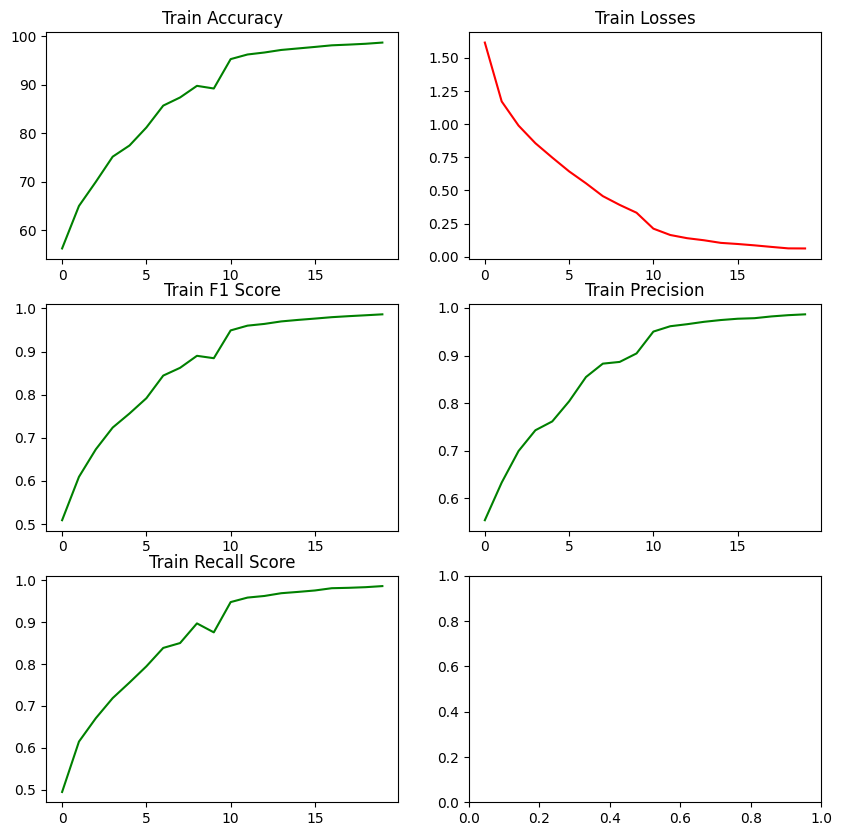

In [50]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(train_metrics['accuracy'], color='g')
ax[0,0].set_title('Train Accuracy')

ax[0,1].plot(train_loss_list, color='r')
ax[0,1].set_title('Train Losses')

ax[1,0].plot(train_metrics['f1_score'], color='g')
ax[1,0].set_title('Train F1 Score')

ax[1,1].plot(train_metrics['precision'], color='g')
ax[1,1].set_title('Train Precision')

ax[2,0].plot(train_metrics['recall_score'], color='g')
ax[2,0].set_title('Train Recall Score')

Text(0.5, 1.0, 'Validation Recall Score')

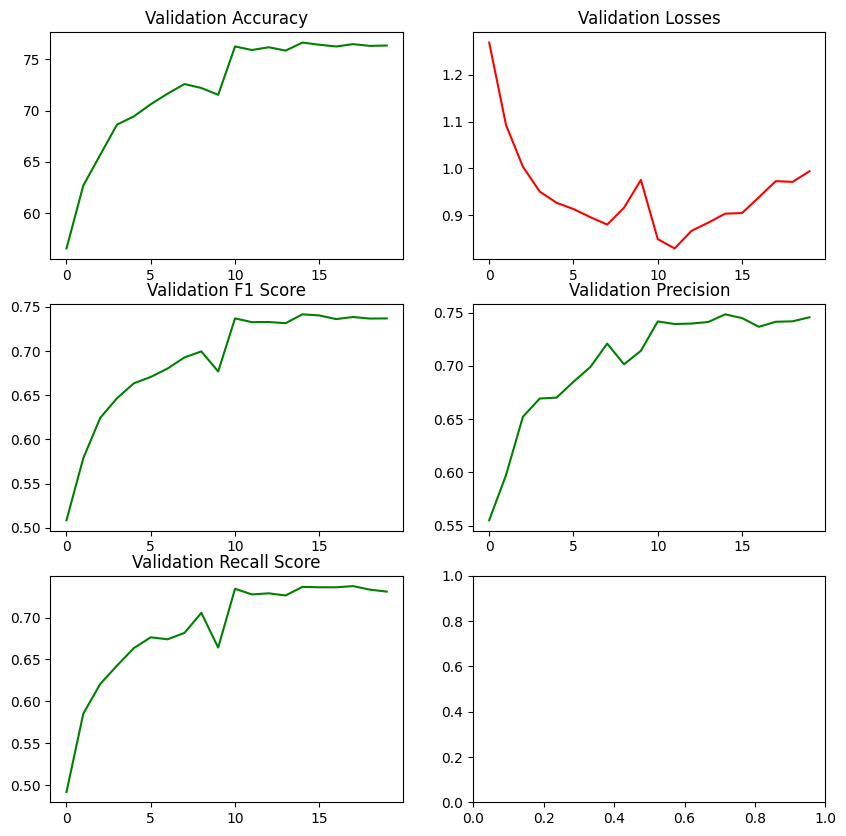

In [51]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(val_metrics['accuracy'], color='g')
ax[0,0].set_title('Validation Accuracy')

ax[0,1].plot(val_loss_list, color='r')
ax[0,1].set_title('Validation Losses')

ax[1,0].plot(val_metrics['f1_score'], color='g')
ax[1,0].set_title('Validation F1 Score')

ax[1,1].plot(val_metrics['precision'], color='g')
ax[1,1].set_title('Validation Precision')

ax[2,0].plot(val_metrics['recall_score'], color='g')
ax[2,0].set_title('Validation Recall Score')

In [52]:
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

In [53]:
print(all_labels)
print(all_preds)

[np.int64(5), np.int64(0), np.int64(1), np.int64(8), np.int64(4), np.int64(2), np.int64(0), np.int64(0), np.int64(8), np.int64(8), np.int64(0), np.int64(0), np.int64(3), np.int64(8), np.int64(0), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(0), np.int64(8), np.int64(3), np.int64(4), np.int64(8), np.int64(9), np.int64(8), np.int64(8), np.int64(0), np.int64(1), np.int64(0), np.int64(7), np.int64(4), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(3), np.int64(1), np.int64(4), np.int64(8), np.int64(4), np.int64(7), np.int64(0), np.int64(7), np.int64(1), np.int64(6), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(0), np.int64(9), np.int64(7), np.int64(8), np.int64(8), np.int64(5), np.int64(0), np.int64(0), np.int64(5), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(9), np.int64(8), np.int64(7), np.int64(9), np.int64(0), np.int64(8), np.int64(8), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(1), np.int64(3)

In [54]:
count_similar = 0
for i in range(len(all_labels)):
  if all_labels[i] == all_preds[i]:
    count_similar += 1

count_similar

4008

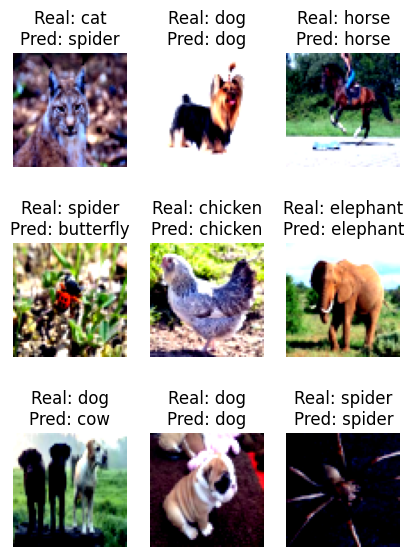

In [55]:
fig, axes = plt.subplots(3, 3, figsize=(5, 7))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = outputs.max(1)

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    img = img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f'Real: {classes_eng[labels[i].item()]}\nPred: {classes_eng[predicted[i].item()]}')
    ax.axis('off')
plt.show()

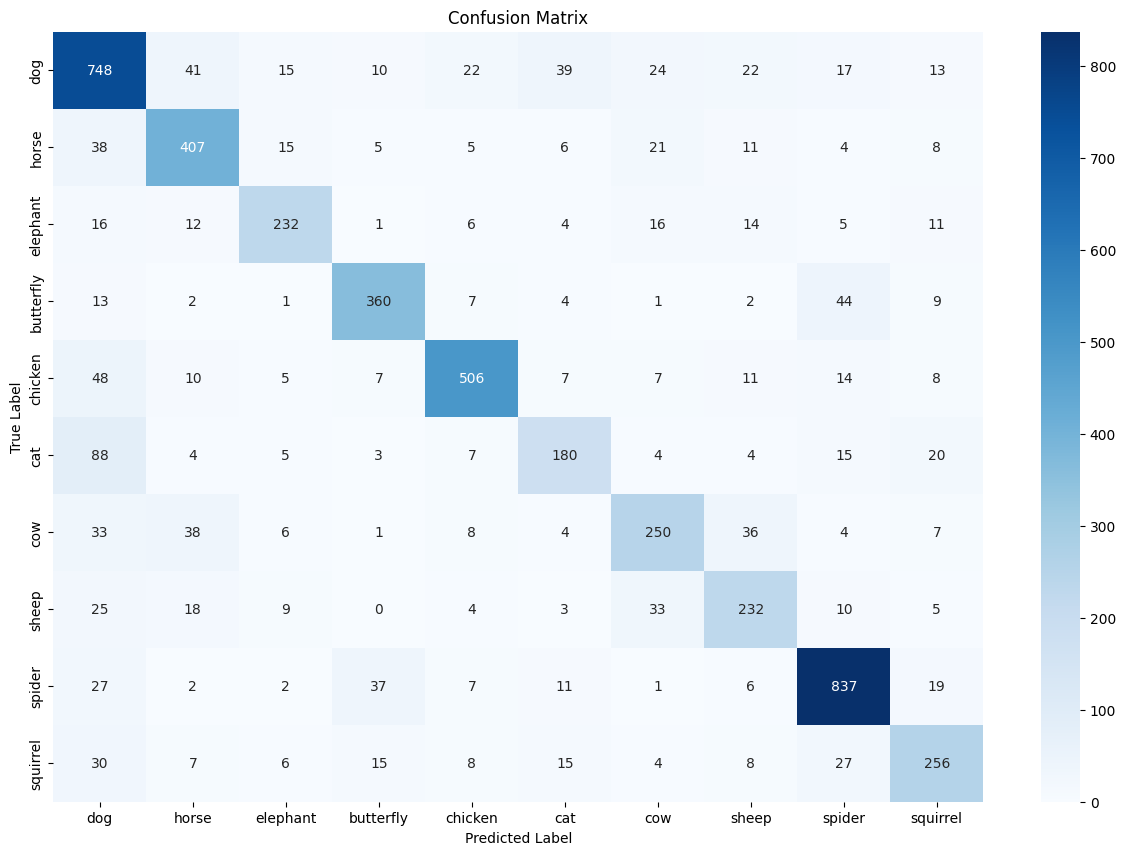

In [56]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_eng, yticklabels=classes_eng)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [57]:
print(classification_report(all_labels, all_preds, target_names=classes_eng))

              precision    recall  f1-score   support

         dog       0.70      0.79      0.74       951
       horse       0.75      0.78      0.77       520
    elephant       0.78      0.73      0.76       317
   butterfly       0.82      0.81      0.82       443
     chicken       0.87      0.81      0.84       623
         cat       0.66      0.55      0.60       330
         cow       0.69      0.65      0.67       387
       sheep       0.67      0.68      0.68       339
      spider       0.86      0.88      0.87       949
    squirrel       0.72      0.68      0.70       376

    accuracy                           0.77      5235
   macro avg       0.75      0.74      0.74      5235
weighted avg       0.77      0.77      0.76      5235



In [68]:
trial_numbers = results_dict["trial_number"]
accuracies = results_dict["accuracy"]
params = results_dict["params"]

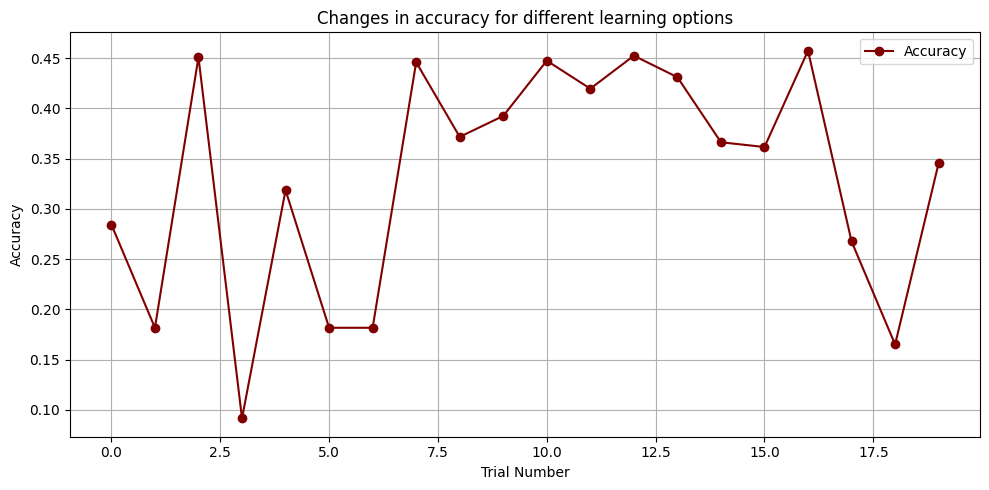

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(trial_numbers, accuracies, marker="o", linestyle="-", color="maroon", label="Accuracy")
plt.xlabel("Trial Number")
plt.ylabel("Accuracy")
plt.title("Changes in accuracy for different learning options")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

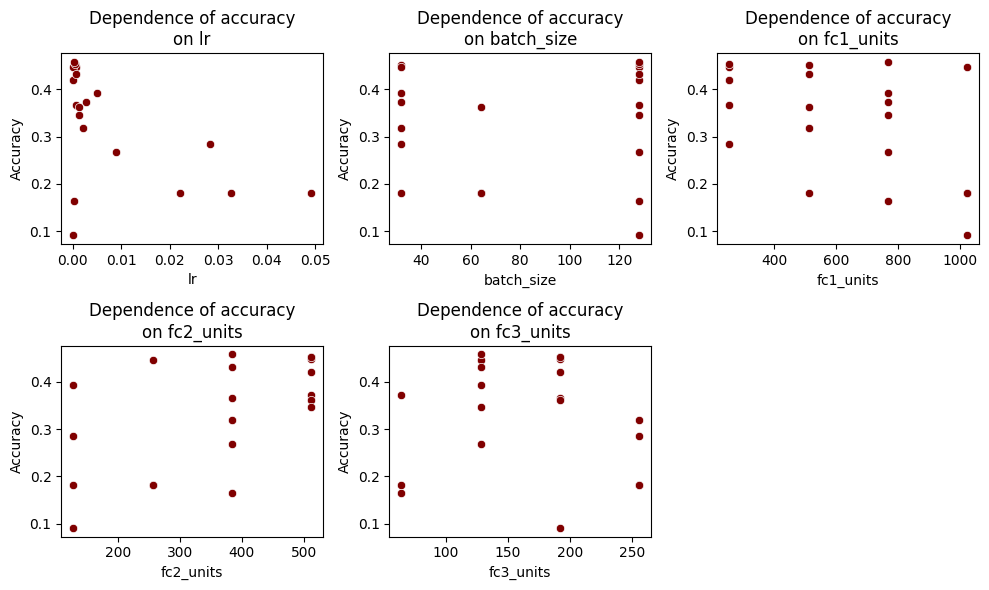

In [71]:
param_names = ['lr', 'batch_size', 'fc1_units', 'fc2_units', 'fc3_units']

plt.figure(figsize=(10, 6))
for i, param in enumerate(param_names):
    plt.subplot(2, 3, i + 1)

    param_values = [entry[param] for entry in results_dict['params']]

    sns.scatterplot(x=param_values, y=results_dict['accuracy'], c='maroon')

    plt.xlabel(param)
    plt.ylabel('Accuracy')
    plt.title(f'Dependence of accuracy\non {param}')

plt.tight_layout()
plt.show()